In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
print("--- Part 1: Hyperparameter Tuning with Grid Search ---")

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("\nDataset Features (X) shape:", X.shape)
print("Dataset Labels (y) shape:", y.shape)
print("Feature Names:", feature_names)
print("Target Names:", target_names)

--- Part 1: Hyperparameter Tuning with Grid Search ---

Dataset Features (X) shape: (150, 4)
Dataset Labels (y) shape: (150,)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape[0], "samples")
print("Test set size:", X_test.shape[0], "samples")


Training set size: 105 samples
Test set size: 45 samples


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized successfully.")


Features standardized successfully.


In [9]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

print("\nHyperparameter grid defined:")

for param, values in param_grid.items():
    print(param, ":", values)


Hyperparameter grid defined:
C : [0.1, 1, 10, 100]
gamma : [1, 0.1, 0.01, 0.001]
kernel : ['rbf', 'linear']


In [11]:
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("\nStarting Grid Search with 5-fold Cross-Validation...")

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed.")


Starting Grid Search with 5-fold Cross-Validation...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Grid Search completed.


In [13]:
print("\nBest hyperparameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{grid_search.best_score_:.4f}")


Best hyperparameters found:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best cross-validation accuracy:
0.9810


In [15]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

test_accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("\nTest set accuracy with tuned model:")
print(f"{test_accuracy_tuned:.4f}")

print("\n--- Classification Report for Tuned Model ---")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=target_names
))


Test set accuracy with tuned model:
0.9111

--- Classification Report for Tuned Model ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45




--- Confusion Matrix for Tuned Model ---


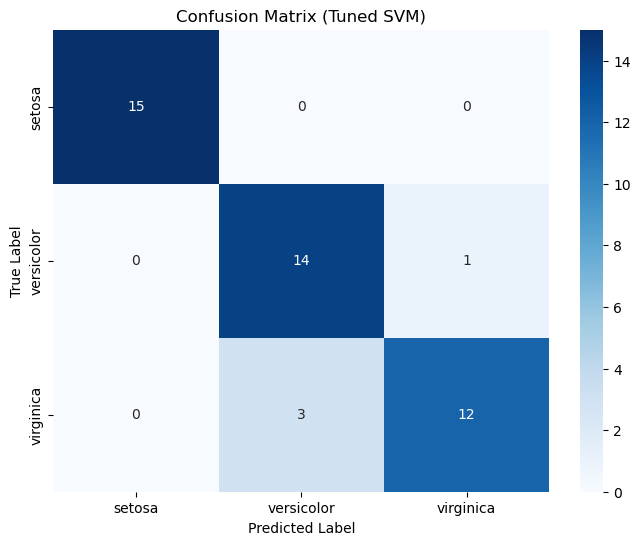

In [17]:
print("\n--- Confusion Matrix for Tuned Model ---")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Confusion Matrix (Tuned SVM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()